In [1]:
""" Problem 7.6.1 """

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as sig
from math import pi, exp, cos, sin, log, sqrt
from control import margin
from control import tf

<>:23: SyntaxWarning: invalid escape sequence '\o'
<>:35: SyntaxWarning: invalid escape sequence '\o'
<>:23: SyntaxWarning: invalid escape sequence '\o'
<>:35: SyntaxWarning: invalid escape sequence '\o'
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_59768\3662823944.py:23: SyntaxWarning: invalid escape sequence '\o'
  plt.text(.3,-40,'$\omega$p = {}'.format(round(wp,1)),fontsize=12)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_59768\3662823944.py:35: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/s)')
C:\Users\Gabriel\anaconda3\Lib\site-packages\scipy\signal\_ltisys.py:600: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


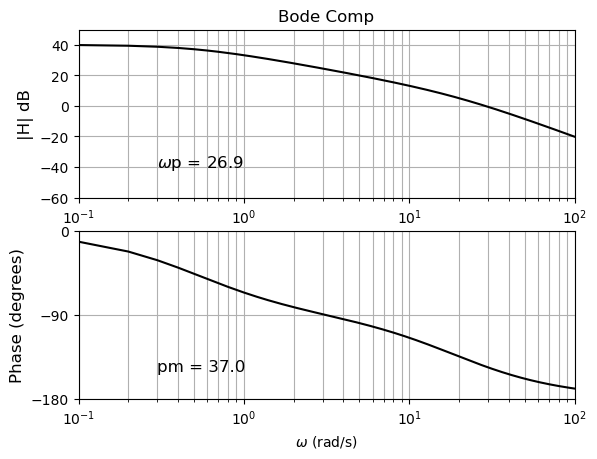

In [2]:
K = 1
n1 = [0, 0, 1000]
d1 = [1, 20, 10]

n2 = [0, 0, 1]
d2 = [0, 0, 1]

n12 = K*np.convolve(n1,n2)
d12 = np.convolve(d1,d2)

num = n12
den = d12

w = np.linspace(0.1,100,num=1000)
system = sig.lti(num,den)
w, Hmag, Hphase = sig.bode(system,w)
gm, pm, wg, wp = margin(Hmag,Hphase,w)

plt.subplot(211)
plt.semilogx(w,Hmag,'k')
plt.axis([ .1, 1e2, -60, 50])
plt.ylabel('|H| dB',size = 12)
plt.text(.3,-40,'$\omega$p = {}'.format(round(wp,1)),fontsize=12)
plt.title('Bode Comp')
plt.grid(which='both')

for n in range(100):
    if Hphase[n] > 0:
        Hphase[n] = Hphase[n] - 360

plt.subplot(212)
plt.semilogx(w,Hphase,'k')
plt.axis([ .1, 1e2, -180,0])
plt.yticks([-180,-90,0])
plt.xlabel('$\omega$ (rad/s)')
plt.ylabel('Phase (degrees)',size=12)
plt.text(.3,-150,'pm = {}'.format(round(pm,0)),fontsize=12)
plt.grid(which='both')
plt.savefig('H_bode.png',dpi=300)
plt.show()

In [3]:
""" Phase Lead Calculations """

p_m = 18 *(np.pi/180)
a = (1+np.sin(p_m))/(1-np.sin(p_m))
w_m = -10*np.log10(a)
print("w_m =", w_m)

w_m = -2.774779185819268


In [4]:
# Use this function to find corresponding w
center_freq = 34.63 #rad/s
w_guess = np.interp(center_freq, w, Hmag)
print(w_m, "=", w_guess)

-2.774779185819268 = -2.773741378352836


In [5]:
w_p = np.sqrt(a)*center_freq
w_z = center_freq/np.sqrt(a)
print("w_m =", center_freq, "rad/s")
print("w_p =", w_p, "rad/s")
print("w_z =", w_z, "rad/s")

w_m = 34.63 rad/s
w_p = 47.66410590591674 rad/s
w_z = 25.16016774482565 rad/s


<>:25: SyntaxWarning: invalid escape sequence '\o'
<>:37: SyntaxWarning: invalid escape sequence '\o'
<>:25: SyntaxWarning: invalid escape sequence '\o'
<>:37: SyntaxWarning: invalid escape sequence '\o'
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_59768\3423587453.py:25: SyntaxWarning: invalid escape sequence '\o'
  plt.text(.3,-40,'$\omega$p = {}'.format(round(wp,1)),fontsize=12)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_59768\3423587453.py:37: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/s)')


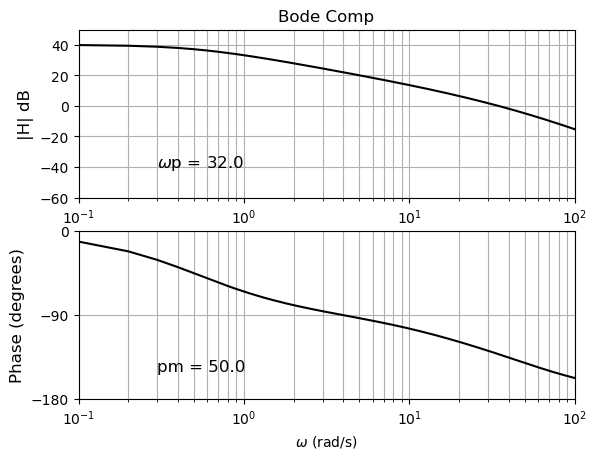

In [6]:
""" Phase Lead Implementation """

K = w_p/w_z
n1 = [0, 0, 1000]
d1 = [1, 20, 10]

n2 = [0, 1, w_z]
d2 = [0, 1, w_p]

n12 = K*np.convolve(n1,n2)
d12 = np.convolve(d1,d2)

num = n12
den = d12

w = np.linspace(0.1,100,num=1000)
system = sig.lti(num,den)
w, Hmag, Hphase = sig.bode(system,w)
gm, pm, wg, wp = margin(Hmag,Hphase,w)

plt.subplot(211)
plt.semilogx(w,Hmag,'k')
plt.axis([ .1, 1e2, -60, 50])
plt.ylabel('|H| dB',size = 12)
plt.text(.3,-40,'$\omega$p = {}'.format(round(wp,1)),fontsize=12)
plt.title('Bode Comp')
plt.grid(which='both')

for n in range(100):
    if Hphase[n] > 0:
        Hphase[n] = Hphase[n] - 360

plt.subplot(212)
plt.semilogx(w,Hphase,'k')
plt.axis([ .1, 1e2, -180,0])
plt.yticks([-180,-90,0])
plt.xlabel('$\omega$ (rad/s)')
plt.ylabel('Phase (degrees)',size=12)
plt.text(.3,-150,'pm = {}'.format(round(pm,0)),fontsize=12)
plt.grid(which='both')
plt.savefig('H_bode.png',dpi=300)
plt.show()